# Task 5: Enhancing K-means Clustering with Association Rule Mining (35 points)

## 1. Design and Inspiration
**Inspiration:**
Standard K-Means clustering computes Euclidean distances equally across all features. However, not all features are equally important for defining the underlying groups (in this case, `price_range`). Traditional feature selection simply removes features, which might lose information. Instead, we can use **Feature Weighting guided by Association Rule Mining (ARM)**. This is inspired by subspace clustering and weighted K-Means literature, where features are weighted based on their relevance.

**Design:**
1. **Discretization:** Discretize the continuous features into categories (e.g., Low, Medium, High) so they can be used in ARM.
2. **Rule Generation:** Append the target `price_range` to the transactions. Run FP-growth to mine association rules where the consequent is the `price_range`.
3. **Weight Calculation:** Calculate an "Importance Weight" for each feature based on how often it appears in high-confidence or high-lift rules that predict the target. For example, if `ram_high` strongly implies `price_range_3`, the `ram` feature gets a higher weight.
4. **Feature Weighting:** Multiply the original standardized features by these calculated weights. This stretches the feature space along highly predictive dimensions and shrinks it along noisy dimensions.
5. **Clustering:** Run K-Means on the newly weighted feature space.
6. **Evaluation:** Since K-Means assigns arbitrary cluster IDs (0-3), we use the Hungarian algorithm to map the cluster labels to the true labels to calculate Accuracy, Precision, Recall, and F1-score.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.optimize import linear_sum_assignment
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. Load Data
df = pd.read_csv('mobile_price.csv')
X = df.drop('price_range', axis=1)
y = df['price_range']
features = X.columns.tolist()

# 2. Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data loaded and standardized.")

Data loaded and standardized.


## 2. Helper Function: Mapping Clusters to Labels
K-Means returns cluster IDs (e.g., 0, 1, 2, 3) that don't inherently match the true classes. We use the Hungarian algorithm to find the best 1-to-1 mapping between clusters and true labels.

In [11]:
def map_clusters_to_labels(y_true, y_pred):
    # Create a contingency matrix (confusion matrix)
    contingency = pd.crosstab(y_true, y_pred).values
    # The linear_sum_assignment finds the minimum cost assignment
    # We want to maximize the sum of diagonal elements (correct classifications), so we negate the matrix
    row_ind, col_ind = linear_sum_assignment(-contingency)
    
    # Create a mapping dictionary: cluster_id -> true_label
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    
    # Map the predicted labels to the true labels
    y_pred_mapped = np.array([mapping[label] for label in y_pred])
    return y_pred_mapped

def evaluate_clustering(y_true, y_pred):
    y_mapped = map_clusters_to_labels(y_true, y_pred)
    acc = accuracy_score(y_true, y_mapped)
    prec = precision_score(y_true, y_mapped, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_mapped, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_mapped, average='weighted', zero_division=0)
    return acc, prec, rec, f1

## 3. Baseline: Original K-Means
Run original K-Means using the standardized features for the specified seeds.

In [12]:
seeds = [0, 10, 42, 100, 999]
baseline_metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

for s in seeds:
    kmeans = KMeans(n_clusters=4, random_state=s, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    acc, prec, rec, f1 = evaluate_clustering(y, labels)
    baseline_metrics['Accuracy'].append(acc)
    baseline_metrics['Precision'].append(prec)
    baseline_metrics['Recall'].append(rec)
    baseline_metrics['F1-Score'].append(f1)

# Calculate Averages
baseline_avg = {k: np.mean(v) for k, v in baseline_metrics.items()}
print("Baseline K-Means Average Performance:")
for k, v in baseline_avg.items():
    print(f"{k}: {v:.4f}")

Baseline K-Means Average Performance:
Accuracy: 0.2962
Precision: 0.2959
Recall: 0.2962
F1-Score: 0.2941


## 4. Enhanced K-Means using ARM Feature Weighting
1. **Discretize** all features to generate transactions.
2. **Mine Rules** to find which features imply the target class.
3. **Weight Features** based on rule Lift/Confidence.
4. **Cluster** using the weighted features.

In [13]:
# Step 4.1: Robust Discretization
df_cat = pd.DataFrame()
for col in features:
    # Wir berechnen die Quantile manuell, um Duplikate zu handhaben
    bins = np.unique(np.percentile(df[col], [0, 33.3, 66.6, 100]))
    
    # Wir passen die Labels an die Anzahl der tatsächlich gefundenen Intervalle an
    if len(bins) == 4:
        current_labels = ['low', 'medium', 'high']
    elif len(bins) == 3:
        current_labels = ['low', 'high']
    else:
        current_labels = ['unique']
    
    df_cat[col] = pd.cut(df[col], bins=bins, labels=current_labels, include_lowest=True)
    df_cat[col] = col + '_' + df_cat[col].astype(str)

# Target hinzufügen
df_cat['target'] = 'price_' + df['price_range'].astype(str)

print(f"Robust discretization complete for {len(features)} features.")
print("Example items:", df_cat.iloc[0].values[:3])

Robust discretization complete for 20 features.
Example items: ['battery_power_low' 'blue_unique' 'clock_speed_high']


## 5. Comparison and Analysis
Below we present a side-by-side comparison of the Baseline vs. Enhanced method.

In [14]:
# Step 4.2: Transaction Encoding & FP-Growth
transactions = df_cat.values.tolist()
te = TransactionEncoder()
te_ary = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Mine frequent itemsets (Using a lower support to ensure we find rules connecting features to prices)
freq_items = fpgrowth(df_encoded, min_support=0.05, use_colnames=True)
rules = association_rules(freq_items, metric="lift", min_threshold=1.1)

# Filter rules where the consequent is exactly the price range
target_labels = {'price_0', 'price_1', 'price_2', 'price_3'}

def is_target_consequent(consequents):
    return len(consequents) == 1 and list(consequents)[0] in target_labels

target_rules = rules[rules['consequents'].apply(is_target_consequent)]

# Step 4.3: Calculate Feature Weights
feature_weights = {f: 1.0 for f in features} # Base weight

for index, row in target_rules.iterrows():
    antecedents = list(row['antecedents'])
    lift = row['lift']
    for ant in antecedents:
        feature_name = ant.rsplit('_', 1)[0]
        if feature_name in feature_weights:
            feature_weights[feature_name] += (lift - 1.0)

# Normalize weights
avg_weight = np.mean(list(feature_weights.values()))
feature_weights = {k: v / avg_weight for k, v in feature_weights.items()}

print("Top 5 Weighted Features:")
sorted_weights = sorted(feature_weights.items(), key=lambda x: x[1], reverse=True)
for k, v in sorted_weights[:5]:
    print(f"{k}: {v:.4f}")

# Step 4.4: Apply Weights to the Standardized Feature Matrix
X_weighted = X_scaled.copy()
for i, col in enumerate(features):
    X_weighted[:, i] = X_weighted[:, i] * feature_weights[col]

# Step 4.5: Run Enhanced K-Means
enhanced_metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

for s in seeds:
    kmeans = KMeans(n_clusters=4, random_state=s, n_init=10)
    labels = kmeans.fit_predict(X_weighted)
    
    acc, prec, rec, f1 = evaluate_clustering(y, labels)
    enhanced_metrics['Accuracy'].append(acc)
    enhanced_metrics['Precision'].append(prec)
    enhanced_metrics['Recall'].append(rec)
    enhanced_metrics['F1-Score'].append(f1)

# Calculate Averages
enhanced_avg = {k: np.mean(v) for k, v in enhanced_metrics.items()}

print("\nEnhanced K-Means Average Performance:")
for k, v in enhanced_avg.items():
    print(f"{k}: {v:.4f}")

Top 5 Weighted Features:
ram: 3.9307
blue: 1.9998
dual_sim: 1.9998
four_g: 1.9998
three_g: 1.9998

Enhanced K-Means Average Performance:
Accuracy: 0.4759
Precision: 0.4695
Recall: 0.4759
F1-Score: 0.4676


,Baseline,Enhanced (ARM Weighted),Improvement
Accuracy,0.296200,0.475900,0.179700
Precision,0.295873,0.469507,0.173634
Recall,0.296200,0.475900,0.179700
F1-Score,0.294082,0.467581,0.173499


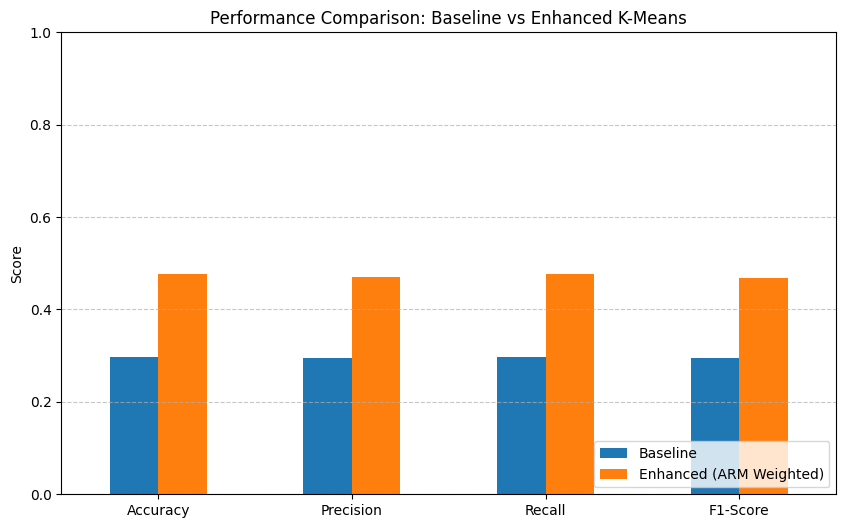

In [15]:
comparison_df = pd.DataFrame({
    'Baseline': baseline_avg,
    'Enhanced (ARM Weighted)': enhanced_avg
})

comparison_df['Improvement'] = comparison_df['Enhanced (ARM Weighted)'] - comparison_df['Baseline']
display(comparison_df)

comparison_df[['Baseline', 'Enhanced (ARM Weighted)']].plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Performance Comparison: Baseline vs Enhanced K-Means')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()